In [1]:
import pandas as pd
import polars as pl
import numpy as np
import os
from tqdm.auto import tqdm
from matplotlib import pyplot as plt
import pickle

from sklearn.metrics import r2_score
from lightgbm import LGBMRegressor
import lightgbm as lgb
from xgboost import XGBRegressor
from sklearn.ensemble import VotingRegressor

import warnings
warnings.filterwarnings('ignore')
pd.options.display.max_columns = None

class CONFIG:
    seed = 42
    target_col = "responder_6"
    feature_cols = ["symbol_id", "time_id"] \
        + [f"feature_{idx:02d}" for idx in range(79)] \
        + [f"responder_{idx}_lag_1" for idx in range(9)]
    categorical_cols = []

/Users/johnny/Library/CloudStorage/OneDrive-Personal/py/JaneStreet2024/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
train = pl.scan_parquet("training.parquet").collect().to_pandas()
valid = pl.scan_parquet("validation.parquet").collect().to_pandas()
train.shape, valid.shape

((8598744, 103), (13505536, 103))

In [3]:
train = pd.concat([train, valid]).reset_index(drop=True)
del valid
train.shape

(22104280, 103)

In [ ]:
import optuna
from xgboost import XGBRegressor
import xgboost as xgb
from optuna_integration import XGBoostPruningCallback
from sklearn.metrics import r2_score
import numpy as np

X_train = train[CONFIG.feature_cols][:15000000]
y_train = train[CONFIG.target_col][:15000000]
w_train = train["weight"][:15000000]
X_valid = train[CONFIG.feature_cols][15000000:]
y_valid = train[CONFIG.target_col][15000000:]
w_valid = train["weight"][15000000:]


def objective(trial):
    XGB_Params = {
        "learning_rate": trial.suggest_uniform("learning_rate", 1e-4, 1e-1),
        "max_depth": trial.suggest_int("max_depth", 6, 12),
        # "n_estimators": trial.suggest_int("n_estimators", 200, 500),
        "subsample": trial.suggest_uniform("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_uniform("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_loguniform("reg_alpha", 1e-3, 10.0),
        "reg_lambda": trial.suggest_loguniform("reg_lambda", 1e-3, 10.0),
        "random_state": CONFIG.seed,
        "eta": trial.suggest_uniform("eta", 0.1, 0.9),
        "tree_method": "hist",
        "max_bin": trial.suggest_int("max_bin", 128, 300),
        "objective": "reg:squarederror",
        "silent": 0,
    }

    num_boost_round = trial.suggest_int("num_boost_round", 80, 500)

    dtrain = xgb.DMatrix(X_train, label=y_train, weight=w_train)
    dvalid = xgb.DMatrix(X_valid, label=y_valid, weight=w_valid)

    # pruning_callback = XGBoostPruningCallback(trial, "validation-rmse")
    evals = [(dvalid, "validation")]

    bst = xgb.train(
        XGB_Params,
        dtrain,
        num_boost_round=num_boost_round,
        evals=evals,
        early_stopping_rounds=4,
        # callbacks=[pruning_callback]
    )

    y_pred_valid = bst.predict(dvalid)
    valid_score = r2_score(y_valid, y_pred_valid, sample_weight=w_valid)
    return valid_score


# Run optimization
# pruner = optuna.pruners.HyperbandPruner(min_resource=5, max_resource=80)
study = optuna.create_study(
    direction="maximize",
    # pruner=pruner,
)
study.optimize(objective, n_trials=200, gc_after_trial=True)

# Best parameters and score
print("Best trial:")
print("  Value: ", study.best_trial.value)
print("  Params: ")
for key, value in study.best_trial.params.items():
    print(f"    {key}: {value}")

In [5]:
def get_model(seed):
    # XGBoost parameters
    XGB_Params = {
        'learning_rate': 0.016860870305925736,
        'max_depth': 8,
        'n_estimators': 481,
        'subsample': 0.706636033556623,
        'colsample_bytree': 0.5711996382110694,
        'reg_alpha': 2.6965864701210585,
        'reg_lambda': 0.0045858564679546725,
        'random_state': seed,
        'tree_method': 'hist',
        'eta': 0.4514438210037096,
        'max_bin': 147,
    }
    
    XGB_Model = XGBRegressor(**XGB_Params)
    return XGB_Model

model = get_model(CONFIG.seed)
model.fit(X_train, y_train, sample_weight=w_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.5711996382110694, device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eta=0.4514438210037096, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.016860870305925736,
             max_bin=147, max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=8, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=481, n_jobs=None,
             num_parallel_tree=None, ...)

In [ ]:
# y_pred_train1 = model.predict(X_train.iloc[:X_train.shape[0]//2])
# y_pred_train2 = model.predict(X_train.iloc[X_train.shape[0]//2:])
# train_score = r2_score(y_train, np.concatenate([y_pred_train1, y_pred_train2], axis=0), sample_weight=w_train )
# train_score

0.2574634552001953

In [6]:
y_pred_valid = model.predict(X_valid)
valid_score = r2_score(y_valid, y_pred_valid, sample_weight=w_valid )
valid_score

0.010264575481414795

In [7]:
y_means = { symbol_id : -1 for symbol_id in range(39) }
for symbol_id, gdf in train[["symbol_id", CONFIG.target_col]].groupby("symbol_id"):
    y_mean = gdf[ CONFIG.target_col ].mean()
    y_means[symbol_id] = y_mean
    print(f"symbol_id = {symbol_id}, y_means = {y_mean:.5f}")

symbol_id = 0, y_means = -0.00098
symbol_id = 1, y_means = -0.00341
symbol_id = 2, y_means = -0.00397
symbol_id = 3, y_means = 0.00723
symbol_id = 4, y_means = 0.01000
symbol_id = 5, y_means = -0.00063
symbol_id = 6, y_means = 0.00344
symbol_id = 7, y_means = 0.00040
symbol_id = 8, y_means = 0.00008
symbol_id = 9, y_means = -0.03597
symbol_id = 10, y_means = 0.00631
symbol_id = 11, y_means = 0.00323
symbol_id = 12, y_means = -0.00015
symbol_id = 13, y_means = -0.01423
symbol_id = 14, y_means = -0.00069
symbol_id = 15, y_means = 0.00938
symbol_id = 16, y_means = 0.00351
symbol_id = 17, y_means = 0.00097
symbol_id = 18, y_means = 0.00169
symbol_id = 19, y_means = 0.01435
symbol_id = 20, y_means = 0.00564
symbol_id = 21, y_means = 0.00550
symbol_id = 22, y_means = -0.00096
symbol_id = 23, y_means = 0.01218
symbol_id = 24, y_means = -0.00468
symbol_id = 25, y_means = -0.01868
symbol_id = 26, y_means = -0.00052
symbol_id = 27, y_means = -0.00559
symbol_id = 28, y_means = -0.00516
symbol_id 

In [9]:
cv_detail = { symbol_id : 0 for symbol_id in range(39) }
# for symbol_id, gdf in train.groupby("symbol_id"):
#     X_valid = gdf[ CONFIG.feature_cols ][15000000:]
#     y_valid = gdf[ CONFIG.target_col ][15000000:]
#     w_valid = gdf[ "weight" ][15000000:]
#     y_pred_valid = model.predict(X_valid)
#     score = r2_score(y_valid, y_pred_valid, sample_weight=w_valid )
#     cv_detail[symbol_id] = score
    
#     print(f"symbol_id = {symbol_id}, score = {score:.5f}")

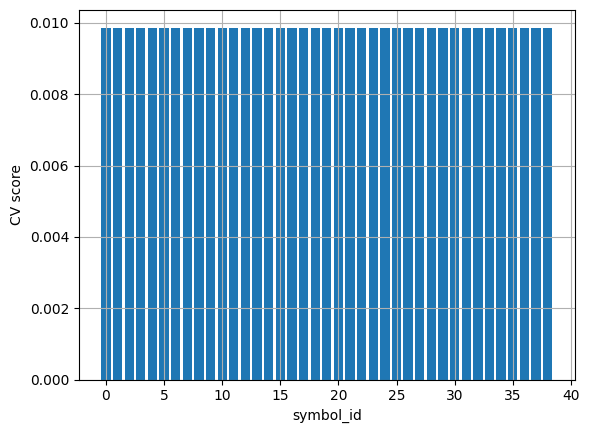

In [ ]:
sids = list(cv_detail.keys())
plt.bar(sids, [cv_detail[sid] for sid in sids])
plt.grid()
plt.xlabel("symbol_id")
plt.ylabel("CV score")
plt.show()

In [10]:
result = {
    "model" : model,
    "cv" : valid_score,
    "cv_detail" : cv_detail,
    "y_mean" : y_means,
}
with open("result.pkl", "wb") as fp:
    pickle.dump(result, fp)